## Де зберігається код

Ноутбук: https://colab.research.google.com/drive/1-OU0rRoFD9GDYhzrTUKKtsrtd3RZ-aT6#scrollTo=5WRI_n3MSfFu

**Як запустити:** відкрити посилання, вставити свій OPENAI_API_KEY через Colab Secrets (🔑 на панелі зліва, назва секрету `OPENAI_API_KEY`), запустити комірки послідовно зверху вниз (Shift+Enter).

In [1]:
!pip install --quiet openai==2.44.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00


In [2]:
# To set 'OPENAI_API_KEY' in Colab Secrets:
# 1. Click the 'key' icon (🔑) on the left sidebar.
# 2. Click 'Add new secret'.
# 3. Set 'Name' to 'OPENAI_API_KEY' and 'Value' to your API key.
# 4. Ensure 'Notebook access' is enabled for this notebook.
import os

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("✅ Ключ з Colab Secrets")
except Exception:
    import getpass
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")
    print("✅ Ключ встановлено")

✅ Ключ з Colab Secrets


In [3]:
from openai import OpenAI
import numpy as np

client = OpenAI()

# Перевірка
resp = client.embeddings.create(model="text-embedding-3-small", input=["test"])
print(f"✅ API працює. Розмір вектора: {np.array(resp.data[0].embedding).shape}")

✅ API працює. Розмір вектора: (1536,)


## Завдання 1. Ембеддінги та матриці схожості (25 балів)

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

# ✏️ ЗАМІНИ на свої речення (5-7 штук)
sentences = [
    "Яка формула площі кола?",
    "Підкажи формулу для обчислення площі круга.",
    "Через три дні контрольна, склади мені план повторення з математики.",
    "Мені потрібен план підготовки до контрольної, залишилось три дні.",
    "Почему косинус угла может быть отрицательным?",
    "Convert 3.5 atmospheres to pascals.",
    "Яка сьогодні погода в Києві?"
]

response = client.embeddings.create(model="text-embedding-3-small", input=sentences)
embeddings = np.array([item.embedding for item in response.data])
print("Форма:", embeddings.shape)

Форма: (7, 1536)


In [5]:
# Косинусна близькість
cos_sim = cosine_similarity(embeddings)
print("Косинусна близькість:")
print(np.round(cos_sim, 3))

print()
for i, s in enumerate(sentences):
    print(f"  S{i}: {s}")

Косинусна близькість:
[[1.    0.64  0.209 0.098 0.214 0.148 0.119]
 [0.64  1.    0.3   0.206 0.201 0.189 0.124]
 [0.209 0.3   1.    0.681 0.111 0.099 0.118]
 [0.098 0.206 0.681 1.    0.027 0.106 0.156]
 [0.214 0.201 0.111 0.027 1.    0.132 0.124]
 [0.148 0.189 0.099 0.106 0.132 1.    0.099]
 [0.119 0.124 0.118 0.156 0.124 0.099 1.   ]]

  S0: Яка формула площі кола?
  S1: Підкажи формулу для обчислення площі круга.
  S2: Через три дні контрольна, склади мені план повторення з математики.
  S3: Мені потрібен план підготовки до контрольної, залишилось три дні.
  S4: Почему косинус угла может быть отрицательным?
  S5: Convert 3.5 atmospheres to pascals.
  S6: Яка сьогодні погода в Києві?


In [10]:
# Евклідова відстань
n = len(sentences)
euclid = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        euclid[i, j] = np.linalg.norm(embeddings[i] - embeddings[j])

print("Евклідова відстань:")
print(np.round(euclid, 3))

Евклідова відстань:
[[0.    0.848 1.258 1.343 1.254 1.305 1.327]
 [0.848 0.    1.184 1.26  1.264 1.274 1.323]
 [1.258 1.184 0.    0.798 1.334 1.343 1.328]
 [1.343 1.26  0.798 0.    1.395 1.337 1.299]
 [1.254 1.264 1.334 1.395 0.    1.318 1.324]
 [1.305 1.274 1.343 1.337 1.318 0.    1.343]
 [1.327 1.323 1.328 1.299 1.324 1.343 0.   ]]


### ✍️ Інтерпретація
<!-- ✏️ НАПИШИ свій аналіз -->


Найбільш схожою парою виявились S2 та S3 (0.681) — обидва речення про план підготовки до контрольної, сформульовані різними словами. Друга за схожістю пара — S0 та S1 (0.64), про формулу площі кола. В обох випадках висока схожість пояснюється специфічною, тематично вузькою лексикою, спільною для пари ("контрольна", "план" у S2/S3; "формула", "площа" у S0/S1), а не довжиною тексту.

Речення S4 (російською, про косинус кута) виявилося найближчим не до S5 (англійською, про конвертацію одиниць), а до S0 і S1 (0.214 і 0.201) — тобто модель об'єднала S4 радше за темою (формули, математика), ніж за мовою. Це підтверджує, що ембеддінги OpenAI мультиязичні і не групують текст за мовою написання, а за змістом.

Речення S6 (про погоду в Києві) не пов'язане з жодним іншим за темою, і це видно не за абсолютно низьким значенням (значення 0.099-0.156 не набагато нижчі за фоновий рівень інших пар), а за відсутністю вираженого піку: жоден сусід не дає значення, близького до 0.6-0.7, як у тематичних пар. Це і є ознака ізольованого, нетематичного запиту в наборі: судити про "чужорідність" тексту варто за відсутністю максимуму, а не за близькістю до нуля.

## Завдання 2. Візуалізація (PCA) (15 балів)

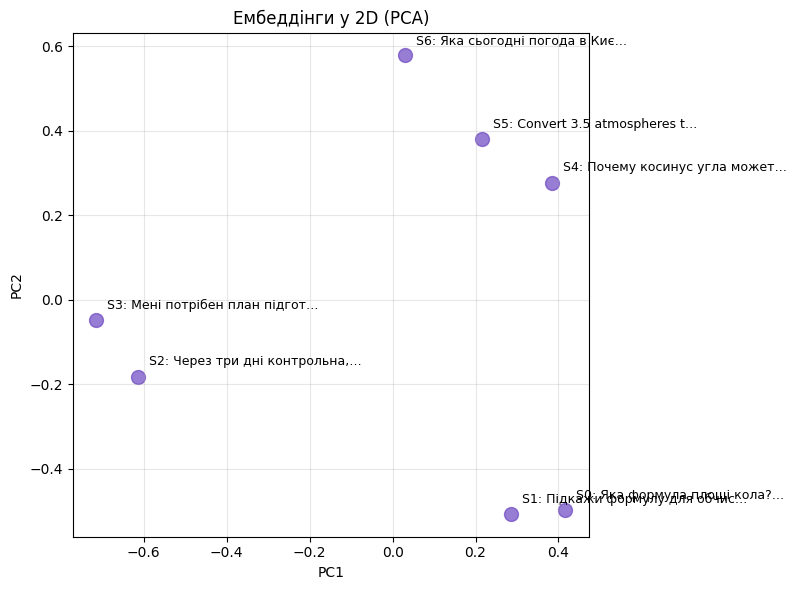

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

embeddings_2d = PCA(n_components=2).fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=100, c='#6B46C1', alpha=0.7)

for i, txt in enumerate(sentences):
    plt.annotate(f"S{i}: {txt[:25]}…", (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 textcoords="offset points", xytext=(8, 8), fontsize=9)

plt.title("Ембеддінги у 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ✍️ Інтерпретація
<!-- ✏️ НАПИШИ свій аналіз -->
На графіку чітко видно два кластери: (S0, S1)  та (S2, S3) про план підготовки до контрольної, що збігається с Завданням 1. Водночас точки S4, S5, S6 розкидані по різних кутах графіка, хоча в повній 1536-вимірній матриці жодна з них не була по-справжньому ізольованою: PCA-проєкція у 2D неминуче втрачає частину інформації і може перебільшувати візуальну відстань між текстами, які насправді помірно пов'язані.

## Завдання 3. Векторний індекс і пошук (30 балів)

In [7]:
from sklearn.neighbors import NearestNeighbors

# ✏️ ЗАМІНИ на свої документи (5-7 штук)
documents = [
    "StudyMate — освітній асистент для учнів старшої школи і студентів перших курсів, що спеціалізується на математиці та частково на фізиці.",
    "Довідник формул StudyMate містить перевірені математичні формули: площі фігур, тригонометричні тотожності, прогресії, і система шукає відповідь саме там, а не генерує її сама.",
    "Калькулятор конвертації одиниць StudyMate виконує переведення фізичних величин (тиск, довжина, маса) через окремий детермінований модуль, а не через мовну модель.",
    "Плановий модуль StudyMate розподіляє час підготовки між темами на основі дедлайну іспиту і заявлених слабких місць учня.",
    "Хімія свідомо виключена з переліку тем StudyMate, оскільки автор продукту не має достатньої експертизи для перевірки якості відповідей з цього предмета.",
    "StudyMate не розв'язує повні контрольні роботи під ключ, щоб не заохочувати списування, а лише допомагає зрозуміти формулу чи логіку розв'язку.",
    "Головна архітектурна вимога StudyMate: відповідь має спиратись виключно на дані з довідника, без додумування моделлю, коли точного збігу не знайдено."
]

doc_response = client.embeddings.create(model="text-embedding-3-small", input=documents)
doc_embeddings = np.array([item.embedding for item in doc_response.data])
print(f"Проіндексовано: {len(documents)} документів")

Проіндексовано: 7 документів


In [8]:
nn = NearestNeighbors(n_neighbors=2, metric='cosine')
nn.fit(doc_embeddings)

# ✏️ ЗАМІНИ на свій запит
query = "Я студент третього курсу фізико-математичного факультету, чи буде мені корисний StudyMate?"

query_emb = np.array([client.embeddings.create(
    model="text-embedding-3-small", input=[query]
).data[0].embedding])

distances, indices = nn.kneighbors(query_emb)

print(f"Запит: '{query}'\n")
for dist, idx in zip(distances[0], indices[0]):
    print(f"  [{1-dist:.3f}] \"{documents[idx]}\"")

Запит: 'Я студент третього курсу фізико-математичного факультету, чи буде мені корисний StudyMate?'

  [0.666] "StudyMate — освітній асистент для учнів старшої школи і студентів перших курсів, що спеціалізується на математиці та частково на фізиці."
  [0.542] "Довідник формул StudyMate містить перевірені математичні формули: площі фігур, тригонометричні тотожності, прогресії, і система шукає відповідь саме там, а не генерує її сама."


### ✍️ Інтерпретація
<!-- ✏️ НАПИШИ свій аналіз -->
Найближчим до запиту виявився документ про цільову аудиторію продукту (схожість 0.666),це правильно, другим - документ про довідник формул. Обидва тематично пов'язані із запитом, але жоден не дає прямої відповіді  на питання користувача, чи підходить йому продукт: третьокурсник фізико-математичного факультету перебуває на межі заявленої аудиторії ("старша школа і перші курси"), і саме ця межовість, ймовірно, і пояснює помірну схожість (0.666, проти 0.64-0.68 у прямих перефразуваннях із Завдання 1). Це показує межу чистого retrieval: пошук знаходить релевантний фрагмент, але зробити з нього висновок для конкретної ситуації користувача має вже LLM на наступному кроці, .

## Завдання 4. Семантичний пошук + LLM-енрічмент (20 балів)

In [9]:
# ✏️ ЗАМІНИ на свій запит
new_query = "Чи підходить StudyMate для підготовки з хімії?"

new_query_emb = np.array([client.embeddings.create(
    model="text-embedding-3-small", input=[new_query]
).data[0].embedding])

nn_3 = NearestNeighbors(n_neighbors=3, metric='cosine')
nn_3.fit(doc_embeddings)
dists, inds = nn_3.kneighbors(new_query_emb)

print(f"Запит: '{new_query}'\n")

for i, (d, idx) in enumerate(zip(dists[0], inds[0]), start=1):
    doc = documents[idx]
    print(f"Сусід {i} [{1-d:.3f}]: \"{doc}\"")

    resp = client.responses.create(
        model="gpt-4o-mini",
        input=(
            f"Запит: {new_query}\n"
            f"Документ: {doc}\n\n"
            "Одним реченням українською поясни, чому документ релевантний запиту."
        )
    )
    print(f"  💬 {resp.output[0].content[0].text.strip()}\n")

Запит: 'Чи підходить StudyMate для підготовки з хімії?'

Сусід 1 [0.668]: "Хімія свідомо виключена з переліку тем StudyMate, оскільки автор продукту не має достатньої експертизи для перевірки якості відповідей з цього предмета."
  💬 Документ релевантний запиту, оскільки містить інформацію про те, що хімія не є доступною темою для підготовки в StudyMate через недостатню експертизу автора.

Сусід 2 [0.554]: "StudyMate — освітній асистент для учнів старшої школи і студентів перших курсів, що спеціалізується на математиці та частково на фізиці."
  💬 Документ релевантний запиту, оскільки зазначає, що StudyMate спеціалізується на математичних і фізичних темах, але не згадує про хімію, що може свідчити про його обмежене застосування в цій галузі.

Сусід 3 [0.543]: "Плановий модуль StudyMate розподіляє час підготовки між темами на основі дедлайну іспиту і заявлених слабких місць учня."
  💬 Документ релевантний запиту, оскільки описує, як StudyMate допомагає організувати підготовку з хімії, вра

### ✍️ Інтерпретація
<!-- ✏️ НАПИШИ свій аналіз -->
Судячи з отриманих значень, документи зі схожістю нижче ≈0.55 вже дають ризик нерелевантного або вигаданого контенту (сусід 3, 0.543). Розумним емпіричним порогом для цього набору виглядає значення близько 0.55-0.6, нижче якого документ краще не передавати в LLM, а видавати користувачу чесне "релевантної інформації не знайдено". Втім, це гіпотеза на малій вибірці (7 документів, 1 запит) — точний поріг для продукційної системи потребує перевірки на більшій кількості реальних запитів.